# 04 — Comparative Results: BERT vs Local LLM

Load saved metrics from `results/bert/` and `results/llm/`, build comparison tables and plots for the final report.

**Methods compared**
- Fine-tuned DistilBERT (5-fold CV)
- SmolLM2-1.7B zero-shot prompting
- SmolLM2-1.7B few-shot prompting

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import LABELS, N_FOLDS, RESULTS_DIR

sns.set_theme(style="whitegrid")
COMPARISON_DIR = RESULTS_DIR / "comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

METHODS = {
    "BERT": RESULTS_DIR / "bert" / "all_folds_metrics.csv",
    "LLM zero-shot": RESULTS_DIR / "llm" / "zero_shot" / "all_folds_metrics.csv",
    "LLM few-shot": RESULTS_DIR / "llm" / "few_shot" / "all_folds_metrics.csv",
}

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\yusuf\OneDrive\Desktop\vscode\FuzzyLogic\final


## 1. Load results and verify completeness

In [2]:
def load_method_metrics(path: Path, method_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["method_display"] = method_name
    return df


frames = {}
for name, path in METHODS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing results: {path}")
    frames[name] = load_method_metrics(path, name)

for name, df in frames.items():
    folds = sorted(df["fold"].unique())
    print(f"{name}: folds {folds} ({len(folds)}/{N_FOLDS})")

bert_df = frames["BERT"]
zero_df = frames["LLM zero-shot"]
few_df = frames["LLM few-shot"]

BERT: folds [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] (5/5)
LLM zero-shot: folds [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] (5/5)
LLM few-shot: folds [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] (5/5)


## 2. Main comparison table (macro / micro F1, mean ± std)

In [3]:
def fold_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("fold")[["macro_f1", "micro_f1"]]
        .first()
        .reset_index()
        .sort_values("fold")
    )


def overall_summary_row(method_name: str, df: pd.DataFrame) -> dict:
    fold_stats = df.groupby("fold").first()[["macro_f1", "micro_f1"]]
    return {
        "Method": method_name,
        "Macro F1 (mean)": fold_stats["macro_f1"].mean(),
        "Macro F1 (std)": fold_stats["macro_f1"].std(ddof=1),
        "Micro F1 (mean)": fold_stats["micro_f1"].mean(),
        "Micro F1 (std)": fold_stats["micro_f1"].std(ddof=1),
    }


comparison_summary = pd.DataFrame(
    [
        overall_summary_row("BERT", bert_df),
        overall_summary_row("LLM zero-shot", zero_df),
        overall_summary_row("LLM few-shot", few_df),
    ]
).round(4)

display(comparison_summary)

comparison_summary.to_csv(COMPARISON_DIR / "comparison_summary.csv", index=False)
print(f"Saved: {COMPARISON_DIR / 'comparison_summary.csv'}")

,Method,Macro F1 (mean),Macro F1 (std),Micro F1 (mean),Micro F1 (std)
0,BERT,0.4244,0.0299,0.7626,0.0061
1,LLM zero-shot,0.1407,0.0014,0.1557,0.0012
2,LLM few-shot,0.1753,0.0018,0.1705,0.0014


Saved: C:\Users\yusuf\OneDrive\Desktop\vscode\FuzzyLogic\final\results\comparison\comparison_summary.csv


## 3. Per-fold macro / micro F1 (all methods)

In [4]:
fold_rows = []
for method_name, df in frames.items():
    summary = fold_summary_table(df)
    summary["Method"] = method_name
    fold_rows.append(summary)

per_fold_all = pd.concat(fold_rows, ignore_index=True)
display(
    per_fold_all.pivot(index="fold", columns="Method", values=["macro_f1", "micro_f1"]).round(4)
)

per_fold_all.to_csv(COMPARISON_DIR / "per_fold_all_methods.csv", index=False)

macro_f1                            micro_f1                           
Method     BERT LLM few-shot LLM zero-shot     BERT LLM few-shot LLM zero-shot
fold                                                                          
0        0.4012       0.1747        0.1385   0.7668       0.1693        0.1538
1        0.4663       0.1785        0.1405   0.7681       0.1727        0.1553
2        0.4431       0.1745        0.1420   0.7567       0.1711        0.1569
3        0.4164       0.1741        0.1416   0.7663       0.1698        0.1566
4        0.3947       0.1745        0.1410   0.7554       0.1697        0.1558

## 4. Per-label metrics (mean ± std across folds)

In [5]:
def per_label_summary(df: pd.DataFrame, method_name: str) -> pd.DataFrame:
    stats = (
        df.groupby("label")[["precision", "recall", "f1"]]
        .agg(["mean", "std"])
        .round(4)
    )
    stats.columns = [f"{m}_{s}" for m, s in stats.columns]
    stats = stats.reset_index()
    stats.insert(0, "Method", method_name)
    return stats


per_label_rows = [
    per_label_summary(bert_df, "BERT"),
    per_label_summary(zero_df, "LLM zero-shot"),
    per_label_summary(few_df, "LLM few-shot"),
]
per_label_summary_df = pd.concat(per_label_rows, ignore_index=True)
display(per_label_summary_df)

per_label_summary_df.to_csv(COMPARISON_DIR / "per_label_summary.csv", index=False)
print(f"Saved: {COMPARISON_DIR / 'per_label_summary.csv'}")

,Method,label,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,BERT,identity_hate,0.2000,0.4472,0.0091,0.0203,0.0174,0.0389
1,BERT,insult,0.7600,0.0192,0.7180,0.0547,0.7369,0.0225
2,BERT,obscene,0.8577,0.0368,0.8187,0.0275,0.8368,0.0085
3,BERT,severe_toxic,0.2682,0.2625,0.0920,0.1026,0.1348,0.1452
4,BERT,threat,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,BERT,toxic,0.8280,0.0344,0.8143,0.0357,0.8202,0.0167
6,LLM zero-shot,identity_hate,0.0286,0.0010,0.9636,0.0203,0.0555,0.0019
7,LLM zero-shot,insult,0.1497,0.0016,0.9100,0.0113,0.2571,0.0021
8,LLM zero-shot,obscene,0.1595,0.0022,0.9011,0.0159,0.2710,0.0035
9,LLM zero-shot,severe_toxic,0.0323,0.0008,0.9720,0.0228,0.0625,0.0015


Saved: C:\Users\yusuf\OneDrive\Desktop\vscode\FuzzyLogic\final\results\comparison\per_label_summary.csv


## 5. Visualizations

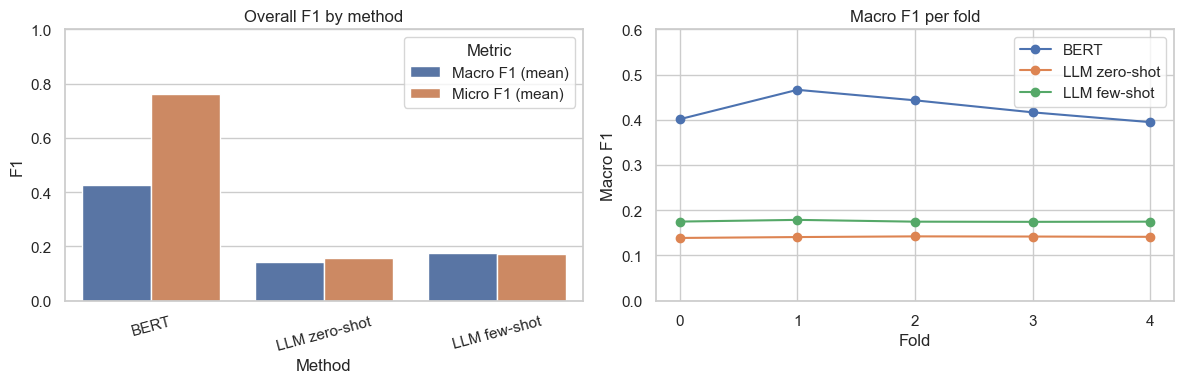

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df = comparison_summary.melt(
    id_vars="Method",
    value_vars=["Macro F1 (mean)", "Micro F1 (mean)"],
    var_name="Metric",
    value_name="F1",
)
sns.barplot(data=plot_df, x="Method", y="F1", hue="Metric", ax=axes[0])
axes[0].set_title("Overall F1 by method")
axes[0].tick_params(axis="x", rotation=15)
axes[0].set_ylim(0, 1)

for method_name, df in frames.items():
    fold_stats = fold_summary_table(df)
    axes[1].plot(fold_stats["fold"], fold_stats["macro_f1"], marker="o", label=method_name)
axes[1].set_title("Macro F1 per fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Macro F1")
axes[1].set_xticks(range(N_FOLDS))
axes[1].legend()
axes[1].set_ylim(0, 0.6)

plt.tight_layout()
plt.savefig(COMPARISON_DIR / "overall_and_fold_macro_f1.png", dpi=150, bbox_inches="tight")
plt.show()

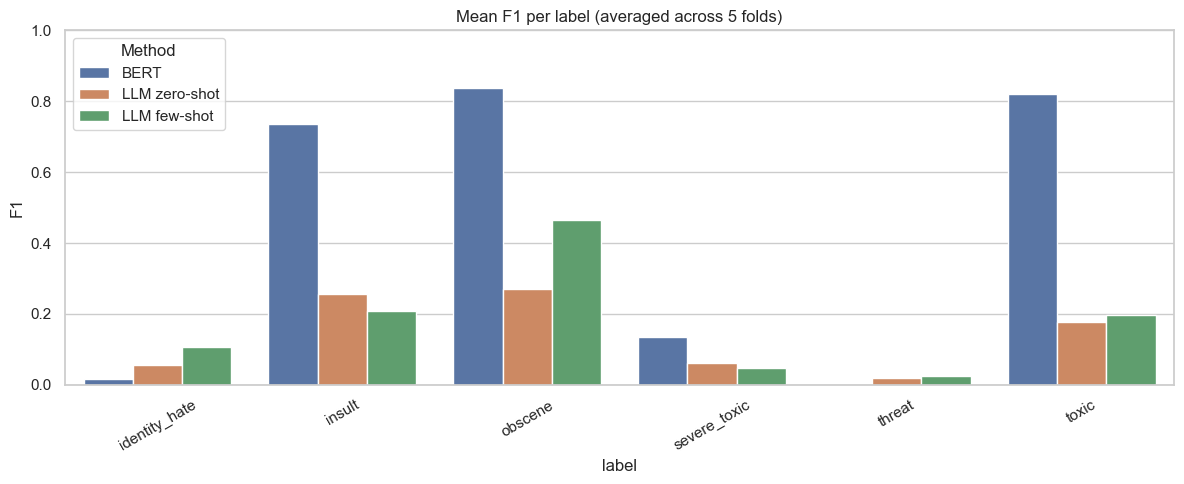

In [7]:
f1_compare_rows = []
for method_name, df in frames.items():
    label_means = df.groupby("label")["f1"].mean().reset_index()
    label_means["Method"] = method_name
    f1_compare_rows.append(label_means)

f1_compare = pd.concat(f1_compare_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=f1_compare, x="label", y="f1", hue="Method", ax=ax)
ax.set_title("Mean F1 per label (averaged across 5 folds)")
ax.set_ylabel("F1")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(COMPARISON_DIR / "per_label_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Detailed per-fold tables (for report appendix)

Each table shows per-label Precision, Recall, and F1 for one method and one fold.

In [8]:
def per_fold_label_table(df: pd.DataFrame, method_name: str) -> None:
    for fold_idx in sorted(df["fold"].unique()):
        subset = df[df["fold"] == fold_idx][["label", "precision", "recall", "f1"]].round(4)
        macro = df[df["fold"] == fold_idx]["macro_f1"].iloc[0]
        micro = df[df["fold"] == fold_idx]["micro_f1"].iloc[0]
        print(f"\n{method_name} — Fold {fold_idx} | macro F1={macro:.4f}, micro F1={micro:.4f}")
        display(subset)


for method_name, df in frames.items():
    per_fold_label_table(df, method_name)


BERT — Fold 0 | macro F1=0.4012, micro F1=0.7668


,label,precision,recall,f1
0,toxic,0.8238,0.8392,0.8314
1,severe_toxic,0.0000,0.0000,0.0000
2,obscene,0.9035,0.7774,0.8357
3,threat,0.0000,0.0000,0.0000
4,insult,0.7479,0.7328,0.7403
5,identity_hate,0.0000,0.0000,0.0000



BERT — Fold 1 | macro F1=0.4663, micro F1=0.7681


,label,precision,recall,f1
6,toxic,0.8252,0.8079,0.8165
7,severe_toxic,0.4783,0.2200,0.3014
8,obscene,0.8272,0.8491,0.8380
9,threat,0.0000,0.0000,0.0000
10,insult,0.7490,0.7611,0.7550
11,identity_hate,1.0000,0.0455,0.0870



BERT — Fold 2 | macro F1=0.4431, micro F1=0.7567


...

,label,precision,recall,f1
12,toxic,0.1098,0.9645,0.1971
13,severe_toxic,0.0253,0.9600,0.0493
14,obscene,0.3384,0.7576,0.4678
15,threat,0.0113,0.8667,0.0222
16,insult,0.1187,0.9106,0.2100
17,identity_hate,0.0538,0.7727,0.1006



LLM few-shot — Fold 3 | macro F1=0.1741, micro F1=0.1698


,label,precision,recall,f1
18,toxic,0.1088,0.9520,0.1952
19,severe_toxic,0.0250,0.9600,0.0488
20,obscene,0.3333,0.7208,0.4558
21,threat,0.0123,0.9333,0.0243
22,insult,0.1197,0.8988,0.2113
23,identity_hate,0.0585,0.8182,0.1093



LLM few-shot — Fold 4 | macro F1=0.1745, micro F1=0.1697


,label,precision,recall,f1
24,toxic,0.1085,0.9438,0.1947
25,severe_toxic,0.0225,0.8400,0.0438
26,obscene,0.3404,0.7283,0.4639
27,threat,0.0134,1.0000,0.0264
28,insult,0.1197,0.8866,0.2109
29,identity_hate,0.0576,0.8182,0.1076


## 7. Report-ready conclusion (draft)

**Key findings from this comparison:**
- Fine-tuned DistilBERT achieves the highest macro and micro F1 across all folds.
- Local LLM (SmolLM2) under zero-shot and few-shot prompting shows much lower precision and over-predicts toxic labels (high recall, low precision — see per-label tables).
- Few-shot prompting improves LLM macro-F1 over zero-shot, but remains far below supervised BERT.
- Rare labels (`threat`, `identity_hate`) are difficult for all methods; BERT handles frequent labels (`toxic`, `obscene`, `insult`) best.

Exported files for your report are in `results/comparison/`.